# Customer Data Processing

##### Analyszing Flat CSV file and converting into rich data structure

In [2]:
#importing  CSV lib.  for reading the files

In [3]:
import csv
import json
from pprint import pprint
import os

In [4]:
csv_file = 'acw_user_data.csv'

## Read csv file using csv reader

#### open CSV and sample the headers

In [5]:
customer_data_list = []

with open(csv_file, mode='r') as file:    #opening and reading through the csv file
    csv_reader = csv.reader(file)
    
    for row in csv_reader:
        customer_data_list.append(row)      #appending the read file into the created empty list

In [6]:
len(customer_data_list)      #sampling the list  to verify with length as aganist the raw file

1001

In [7]:
customer_data_list[2]                    #sampling row 2 of the customer_data_list data

['00 Wheeler wells',
 'Chapmanton',
 'L2 7BT',
 '46',
 '13.72',
 'Begum-Williams',
 '08/12',
 '11/26',
 '4529436854129855',
 '583',
 '1',
 'Jonathan',
 'GB37UMCO54540228728019',
 'Thomas',
 'married or civil partner',
 '0',
 'False',
 '54016',
 'Male',
 'Nissan',
 'ATS',
 '1996',
 'Coupe']

### Sampling the headers to see which header to use and how to create the rich data structure 


In [8]:
headers = customer_data_list[0]           # Assigning a varible headers to the customer data list

In [9]:
headers

['Address Street',
 'Address City',
 'Address Postcode',
 'Age (Years)',
 'Distance Commuted to Work (Km)',
 'Employer Company',
 'Credit Card Start Date',
 'Credit Card Expiry Date',
 'Credit Card Number',
 'Credit Card CVV',
 'Dependants',
 'First Name',
 'Bank IBAN',
 'Last Name',
 'Marital Status',
 'Yearly Pension (Dollar)',
 'Retired',
 'Yearly Salary (Dollar)',
 'Sex',
 'Vehicle Make',
 'Vehicle Model',
 'Vehicle Year',
 'Vehicle Type']

#### Rename the headers to match the expected output shown in the appendix of the assignment

###### filling out a list of headers manually to match the outsome shown in the appendix saving iit as modified_headers for futhure use

In [10]:
modified_headers = ['street',
 'city',
 'postcode',
 'age',
 'commute_distance',
 'company',
 'start_date',
 'end_date',
 'number',
 'cvv',
 'dependants',
 'first_name',
 'iban',
 'last_name',
 'marital_tatus',
 'pension',
 'retired',
 'salary',
 'sex',
 'make',
 'model',
 'year',
 'category']

### Cast values to their appropriate types and store in a new list
#### Also store details of problematic rows in another list

In [11]:
integer_cast_columns = [3, 8, 9, 10, 15, 17]              #(3 = age, 8 = credit_card_number, 9 = cvv, 10 = dependants, 15 = pension, 17 =  salary)

float_cast_column = 4                                       #commute_distance

customer_data_list_casted = []                             # master list to hold the total customer data after appropriate casting

counter = 1                                                # count the number of rows 

problematic_rows_for_dependants = []

for customer_data in customer_data_list[1:]:               # loop through all lists except the first one (headers)
    new_row_wih_casted_values = []                         #each row of data will be casted and stored in this list as necessary
    for index, value in enumerate(customer_data):
        if index in integer_cast_columns:
            try:
                casted_value = int(value)                    #cast value to integer
            except Exception as e:
                #print(f' An error occurred -> {e}')
                casted_value = 0                               #convert '' to 0 where the value for dependants is blank
                problematic_rows_for_dependants.append({'row': counter, 'col': index, 'value': value})
        elif customer_data.index(value) == 4:
            casted_value = round(float(value), 2)
        else:
            casted_value = value
        new_row_wih_casted_values.append(casted_value)       #stores all casted value 
     #print(new_row_wih_casted_values)
    
    customer_data_list_casted.append(new_row_wih_casted_values)
    counter += 1        #increment the counter

In [12]:
problematic_rows_for_dependants

[{'row': 22, 'col': 10, 'value': ''},
 {'row': 110, 'col': 10, 'value': ''},
 {'row': 180, 'col': 10, 'value': ''},
 {'row': 206, 'col': 10, 'value': ''},
 {'row': 271, 'col': 10, 'value': ''},
 {'row': 273, 'col': 10, 'value': ''},
 {'row': 275, 'col': 10, 'value': ''},
 {'row': 359, 'col': 10, 'value': ''},
 {'row': 461, 'col': 10, 'value': ''},
 {'row': 469, 'col': 10, 'value': ''},
 {'row': 580, 'col': 10, 'value': ''},
 {'row': 637, 'col': 10, 'value': ''},
 {'row': 680, 'col': 10, 'value': ''},
 {'row': 726, 'col': 10, 'value': ''},
 {'row': 823, 'col': 10, 'value': ''},
 {'row': 866, 'col': 10, 'value': ''},
 {'row': 918, 'col': 10, 'value': ''},
 {'row': 932, 'col': 10, 'value': ''},
 {'row': 984, 'col': 10, 'value': ''}]

In [13]:
len(customer_data_list_casted)    #sampling the length of  casted list

1000

In [14]:
customer_data_list_casted[1]   # sampling the first row to verify the casting was effected

['00 Wheeler wells',
 'Chapmanton',
 'L2 7BT',
 46,
 13.72,
 'Begum-Williams',
 '08/12',
 '11/26',
 4529436854129855,
 583,
 1,
 'Jonathan',
 'GB37UMCO54540228728019',
 'Thomas',
 'married or civil partner',
 0,
 'False',
 54016,
 'Male',
 'Nissan',
 'ATS',
 '1996',
 'Coupe']

### Create a list of dictionaries to store the processed customer data

#### Creating the rich structured data for vehicle_keys, address_keys, credit-card_keys into a json structure (readable to both human and system)

In [15]:
vehicle_keys = {'make', 'model', 'year', 'category'}
address_keys = {'city', 'postcode', 'street'}
credit_card_keys = {'cvv', 'end_date', 'number', 'start_date'}

In [16]:
processed = [] # this list will hold dictionaries of processed customer data
for row in customer_data_list_casted:
    combined = dict(zip(modified_headers, row))
    vehicle = {k: combined.pop(k) for k in list(combined) if k in vehicle_keys}
    credit_card = {k: combined.pop(k) for k in list(combined) if k in credit_card_keys}
    address = {k: combined.pop(k) for k in list(combined) if k in address_keys}
    combined['Vehicle'] = vehicle
    combined['Credit Card'] = credit_card
    combined['Address'] = address
    processed.append(combined)

In [17]:
len(processed)

1000

In [18]:
pprint(processed[0:2])           #sampling first 2 customers details

[{'Address': {'city': 'Lake Conor',
              'postcode': 'S71 7XZ',
              'street': '70 Lydia isle'},
  'Credit Card': {'cvv': 875,
                  'end_date': '11/27',
                  'number': 676373692463,
                  'start_date': '08/18'},
  'Vehicle': {'category': 'Pickup',
              'make': 'Hyundai',
              'model': 'Bonneville',
              'year': '2009'},
  'age': 89,
  'commute_distance': 0.0,
  'company': 'N/A',
  'dependants': 3,
  'first_name': 'Kieran',
  'iban': 'GB62PQKB71416034141571',
  'last_name': 'Wilson',
  'marital_tatus': 'married or civil partner',
  'pension': 7257,
  'retired': 'True',
  'salary': 72838,
  'sex': 'Male'},
 {'Address': {'city': 'Chapmanton',
              'postcode': 'L2 7BT',
              'street': '00 Wheeler wells'},
  'Credit Card': {'cvv': 583,
                  'end_date': '11/26',
                  'number': 4529436854129855,
                  'start_date': '08/12'},
  'Vehicle': {'category': 'Coup

### Save Processed.json to disk

#### writing a Json file for a single customer

In [19]:
json_data = json.dumps(processed, indent=2) # convert data to json format and store in in a varialbe Json_data

In [20]:
filename = 'processed.json'
with open(filename, 'w') as file:
    file.write(json_data)
    print(f'{filename} saved successfully!')

processed.json saved successfully!


In [21]:
retired = []
employed = []
for dictionary in processed:
    if dictionary['retired'] == 'True':
        retired.append(dictionary)
    elif dictionary['company'] != 'N/A':
        employed.append(dictionary)

In [22]:
len(retired)

246

In [23]:
len(employed)

754

### Create a function for saving in json format and save the required json files

#### defining a json fuction to save mutiple file

In [24]:
def save_to_json_format(list_of_dicts, json_filename):
    json_data = json.dumps(list_of_dicts)
    try:
        with open(json_filename, 'w') as file:
            file.write(json_data)
            print(f' {json_filename} saved successfully!')
    except OSError as e:
        print(f' Unable to save file to disk --> {e}')

In [25]:
save_to_json_format(processed, 'processed.json')

 processed.json saved successfully!


In [26]:
save_to_json_format(retired, 'retired.json')

 retired.json saved successfully!


In [27]:
save_to_json_format(employed, 'employed.json')

 employed.json saved successfully!


## Credit Cards to be removed

In [28]:
# Import datetime to convert start_date and end_date from string to datetime format

from datetime import datetime

In [29]:
def remove_credit_card(dictionary):
    flag_remove = 'This row should be flagged for removal (> 10 years)'
    flag_keep = 'This row should not be flagged for removal'
    start_date_str = dictionary['Credit Card']['start_date']
    end_date_str = dictionary['Credit Card']['end_date']
    date_diff = datetime.strptime(end_date_str, '%m/%y') - datetime.strptime(start_date_str, '%m/%y')
    date_diff_in_years = (date_diff.days/365.25) # convert difference between end_date and start_date to years
    if date_diff_in_years > 10:
        return dictionary, flag_remove
    else:
        return None, flag_keep

### Compile a list of customers with credit cards to be removed

In [30]:
remove_ccard = []
for dictionary in processed:
    output, flag = remove_credit_card(dictionary)
    if type(output) == dict:   #check if the output is a dictionary and append the dictionary to remove_ccard list
        remove_ccard.append(output)
    else:
        pass    #do nothing and move on

In [31]:
len(remove_ccard)

253

In [32]:
remove_ccard[:2]

[{'age': 46,
  'commute_distance': 13.72,
  'company': 'Begum-Williams',
  'dependants': 1,
  'first_name': 'Jonathan',
  'iban': 'GB37UMCO54540228728019',
  'last_name': 'Thomas',
  'marital_tatus': 'married or civil partner',
  'pension': 0,
  'retired': 'False',
  'salary': 54016,
  'sex': 'Male',
  'Vehicle': {'make': 'Nissan',
   'model': 'ATS',
   'year': '1996',
   'category': 'Coupe'},
  'Credit Card': {'start_date': '08/12',
   'end_date': '11/26',
   'number': 4529436854129855,
   'cvv': 583},
  'Address': {'street': '00 Wheeler wells',
   'city': 'Chapmanton',
   'postcode': 'L2 7BT'}},
 {'age': 43,
  'commute_distance': 20.05,
  'company': 'Clark Group',
  'dependants': 3,
  'first_name': 'Julian',
  'iban': 'GB92PWOB18937027850061',
  'last_name': 'Potter',
  'marital_tatus': 'single',
  'pension': 0,
  'retired': 'False',
  'salary': 96645,
  'sex': 'Male',
  'Vehicle': {'make': 'Lexus',
   'model': 'S-Series',
   'year': '1998',
   'category': 'Van/Minivan'},
  'Credit C

### Test the remove_credit_Cards function using randomly selected single customer data row

#testing the fuctions with a random data to satify it is working

In [33]:
import random

In [34]:
single_customer_data = random.choice(processed)

In [35]:
single_customer_data

{'age': 85,
 'commute_distance': 0.0,
 'company': 'N/A',
 'dependants': 4,
 'first_name': 'Charles',
 'iban': 'GB57RPFB59729369989813',
 'last_name': 'Williams',
 'marital_tatus': 'married or civil partner',
 'pension': 19041,
 'retired': 'True',
 'salary': 94891,
 'sex': 'Male',
 'Vehicle': {'make': 'Maserati',
  'model': '88',
  'year': '2002',
  'category': 'Pickup'},
 'Credit Card': {'start_date': '07/15',
  'end_date': '03/23',
  'number': 4681281865536613,
  'cvv': 2487},
 'Address': {'street': 'Flat 91r White loop',
  'city': 'South Lynne',
  'postcode': 'L33 1HX'}}

In [36]:
output, flag = remove_credit_card(single_customer_data)

In [37]:
flag

'This row should not be flagged for removal'

## Create new data attribute for each customer (Salary-Commute)

In [38]:
### Read from processed.json

In [39]:
with open('processed.json', 'r') as file:
    processed_data = json.load(file)

### Calculate salary per KM of commute for each customer; 
#### if commute distance is not greater than 1KM then salary_commute becomes the value of the salary of the customer

In [40]:
commute = [] # this list will hold processed data in addition to the new data attribute salary_commute

for dictionary in processed_data:
    salary = dictionary['salary']
    commute_KM = dictionary['commute_distance']
    if commute_KM <= 1:
        salary_commute = salary  # assign salary to salary_commute when commute distance not greater than 1KM
    else:
        salary_commute = round(salary/commute_KM, 2) # round down to 2 d.p
    dictionary['Salary-Commute'] = salary_commute  #include salary_commute to each customer's data
    commute.append(dictionary)

In [41]:
commute[:2] # top 2 before sorting by Salary-Commute in ascending order

[{'age': 89,
  'commute_distance': 0.0,
  'company': 'N/A',
  'dependants': 3,
  'first_name': 'Kieran',
  'iban': 'GB62PQKB71416034141571',
  'last_name': 'Wilson',
  'marital_tatus': 'married or civil partner',
  'pension': 7257,
  'retired': 'True',
  'salary': 72838,
  'sex': 'Male',
  'Vehicle': {'make': 'Hyundai',
   'model': 'Bonneville',
   'year': '2009',
   'category': 'Pickup'},
  'Credit Card': {'start_date': '08/18',
   'end_date': '11/27',
   'number': 676373692463,
   'cvv': 875},
  'Address': {'street': '70 Lydia isle',
   'city': 'Lake Conor',
   'postcode': 'S71 7XZ'},
  'Salary-Commute': 72838},
 {'age': 46,
  'commute_distance': 13.72,
  'company': 'Begum-Williams',
  'dependants': 1,
  'first_name': 'Jonathan',
  'iban': 'GB37UMCO54540228728019',
  'last_name': 'Thomas',
  'marital_tatus': 'married or civil partner',
  'pension': 0,
  'retired': 'False',
  'salary': 54016,
  'sex': 'Male',
  'Vehicle': {'make': 'Nissan',
   'model': 'ATS',
   'year': '1996',
   'ca

### sort commute list by Salary-Commute in ascending order

In [42]:
commute.sort(key=lambda customer: customer['Salary-Commute'])

In [43]:
commute[:2] # top 2 rows after sorting by Salary-Commute in ascending order

[{'age': 52,
  'commute_distance': 5.52,
  'company': 'Smith, Birch and Burke',
  'dependants': 2,
  'first_name': 'Graeme',
  'iban': 'GB09ELJH35362236053720',
  'last_name': 'Jackson',
  'marital_tatus': 'single',
  'pension': 0,
  'retired': 'False',
  'salary': 17046,
  'sex': 'Male',
  'Vehicle': {'make': 'Chevrolet',
   'model': 'Rally Wagon 1500',
   'year': '2011',
   'category': 'SUV'},
  'Credit Card': {'start_date': '06/14',
   'end_date': '04/29',
   'number': 4713424668774153,
   'cvv': 3053},
  'Address': {'street': 'Studio 9 Reid lights',
   'city': 'South Ryan',
   'postcode': 'E27 9GY'},
  'Salary-Commute': 3088.04},
 {'age': 30,
  'commute_distance': 5.64,
  'company': 'Wood-Davies',
  'dependants': 1,
  'first_name': 'Janet',
  'iban': 'GB47KCJL06712308674300',
  'last_name': 'Quinn',
  'marital_tatus': 'married or civil partner',
  'pension': 0,
  'retired': 'False',
  'salary': 17428,
  'sex': 'Female',
  'Vehicle': {'make': 'Audi',
   'model': 'Land Cruiser',
   '

In [44]:
## save commute in json format

In [45]:
save_to_json_format(commute, 'commute.json')

 commute.json saved successfully!


## Data Visualisation (using Pandas and Seaborn)

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv(csv_file) # read in the csv file and store in pandas dataframe

In [48]:
df.head()

,Address Street,Address City,Address Postcode,Age (Years),Distance Commuted to Work (Km),Employer Company,Credit Card Start Date,Credit Card Expiry Date,Credit Card Number,Credit Card CVV,...,Last Name,Marital Status,Yearly Pension (Dollar),Retired,Yearly Salary (Dollar),Sex,Vehicle Make,Vehicle Model,Vehicle Year,Vehicle Type
0,70 Lydia isle,Lake Conor,S71 7XZ,89,0.00,NaN,08/18,11/27,676373692463,875,...,Wilson,married or civil partner,7257,True,72838,Male,Hyundai,Bonneville,2009,Pickup
1,00 Wheeler wells,Chapmanton,L2 7BT,46,13.72,Begum-Williams,08/12,11/26,4529436854129855,583,...,Thomas,married or civil partner,0,False,54016,Male,Nissan,ATS,1996,Coupe
2,Studio 33K Joel walk,Randallborough,ME3N 1GH,22,16.02,Hill-Wright,11/19,07/27,4091726363083888495,422,...,Jones,married or civil partner,0,False,68049,Male,GMC,Achieva,2015,"Convertible, Coupe"
3,Studio 46S Bethany lights,East Reece,E10 9RJ,56,19.35,Green LLC,10/17,04/18,4671332769487632633,669,...,Shaw,married or civil partner,0,False,91337,Male,Scion,F150 SuperCrew Cab,1994,Pickup
4,Flat 3 Christine views,Fletcherstad,WS2 9SN,57,5.94,"Hill, Evans and Harrison",04/19,11/27,2245094149128526,659,...,O'Brien,married or civil partner,0,False,18446,Female,Buick,Outback,2020,SUV


In [49]:
df.columns # view all the column headers

Index(['Address Street', 'Address City', 'Address Postcode', 'Age (Years)',
       'Distance Commuted to Work (Km)', 'Employer Company',
       'Credit Card Start Date', 'Credit Card Expiry Date',
       'Credit Card Number', 'Credit Card CVV', 'Dependants', 'First Name',
       'Bank IBAN', 'Last Name', 'Marital Status', 'Yearly Pension (Dollar)',
       'Retired', 'Yearly Salary (Dollar)', 'Sex', 'Vehicle Make',
       'Vehicle Model', 'Vehicle Year', 'Vehicle Type'],
      dtype='object')

In [50]:
salary_series = df['Yearly Salary (Dollar)']

In [51]:
age_series = df['Age (Years)']

In [52]:
mean_salary = salary_series.mean()

In [53]:
mean_salary

np.float64(57814.078)

### Make univariate plot of Age (using age_series above) with bin_width = 5

In [54]:
median_age = age_series.median()

In [55]:
median_age

np.float64(54.0)

In [56]:
bin_width = 5

In [57]:
minimum_age = age_series.min()
maximum_age = age_series.max()

In [58]:
age_range = maximum_age - minimum_age

In [59]:
num_of_bins = int((age_range/bin_width) + 1)

In [60]:
num_of_bins

15

In [61]:
print(f' Number of bins required = {num_of_bins}')

 Number of bins required = 15


## Using Seaborn to make visualization and draw insights

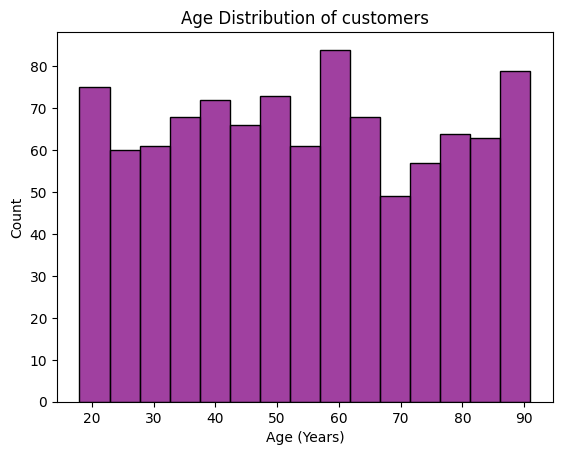

In [63]:
sns.histplot(data=age_series, color='purple', edgecolor='black', binwidth=5)
plt.title("Age Distribution of customers")
plt.savefig("customer_age_distribution.png") # save the plot locally
plt.show()

### Handle the missing values in dependants column and create a univariate plot

In [62]:
df['Dependants'].isna().value_counts() #count the total rows without a number (NaN)

Dependants
False    981
True      19
Name: count, dtype: int64

In [63]:
### replace the missing values with 0
df['Dependants'] = df['Dependants'].fillna(0)

In [64]:
df['Dependants'].isna().value_counts() # checking if all missing values have been filled with 0

Dependants
False    1000
Name: count, dtype: int64

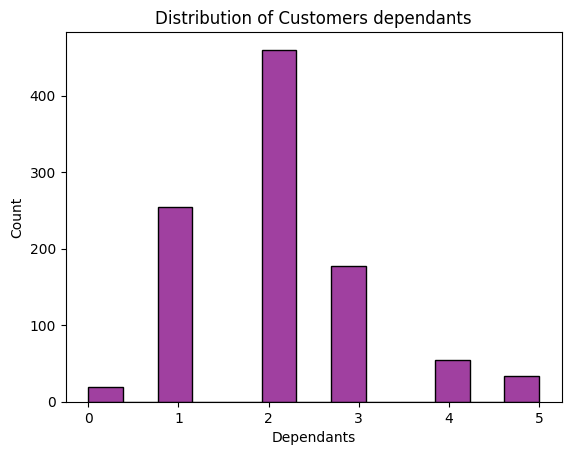

In [65]:
sns.histplot(data=df['Dependants'], color='purple', edgecolor='black')
plt.title('Distribution of Customers dependants')
plt.savefig('dependants_distribution.png')
plt.show()

In [66]:
df['Marital Status'].value_counts() # view breakdown of values in Marital Status column

Marital Status
married or civil partner    541
single                      330
divorced                     71
widowed                      58
Name: count, dtype: int64

### Make a univariate plot of Age conditioned on marital status

In [67]:
custom_palette = {
    'married or civil partner' : 'green',
    'single' : 'purple',
    'divorced' : 'blue',
    'widowed' : 'orange'
}

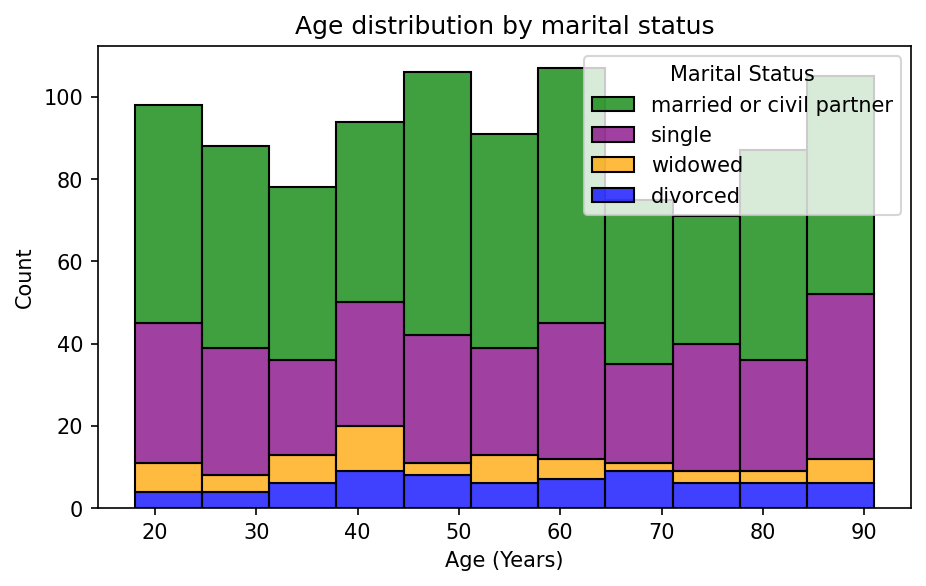

In [68]:
plt.figure(figsize=(7, 4), dpi=150)
sns.histplot(data=df, x='Age (Years)', hue='Marital Status', multiple='stack', palette=custom_palette)
plt.title('Age distribution by marital status')
plt.savefig('age_distribution_by_marital_status.png')
plt.show()

### Make a multivariate plot with commuted distance against salary

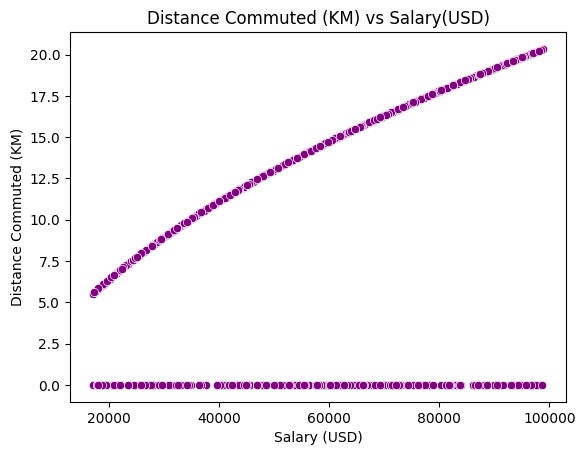

In [69]:
sns.scatterplot(
    data=df,
    x='Yearly Salary (Dollar)',
    y='Distance Commuted to Work (Km)',
    color='purple'
)
plt.title('Distance Commuted (KM) vs Salary(USD)')
plt.xlabel('Salary (USD)')
plt.ylabel('Distance Commuted (KM)')
plt.savefig('distance_commuted_against_salary.png')
plt.show()


### Make a multivariate plot with Age against salary

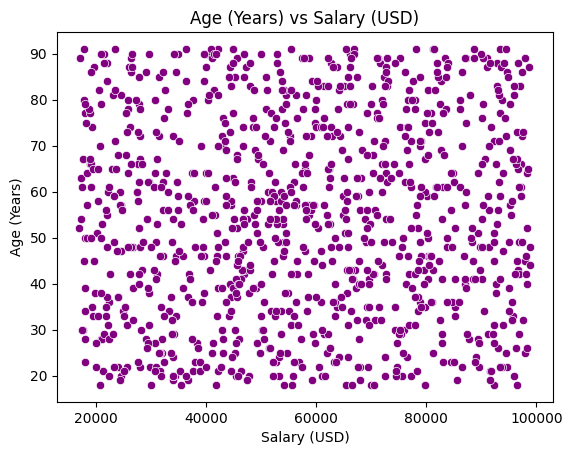

In [70]:
sns.scatterplot(data=df,
                x='Yearly Salary (Dollar)',
                y='Age (Years)',
                color='purple'
)
plt.title('Age (Years) vs Salary (USD)')
plt.xlabel('Salary (USD)')
plt.ylabel('Age (Years)')
plt.savefig('age_against_salary.png')
plt.show()

### Make a multivariate plot with Age against salary conditioned on dependants

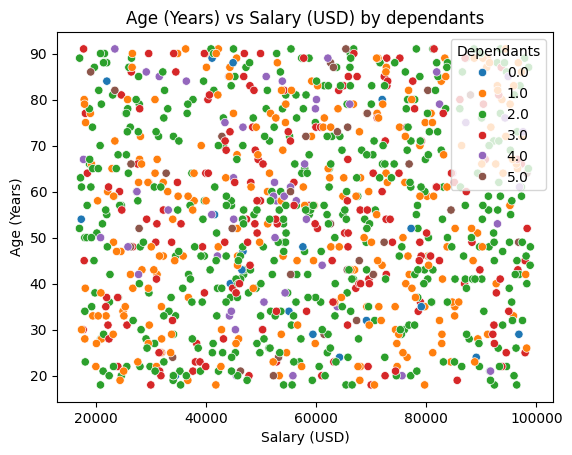

In [71]:
sns.scatterplot(data=df,
                x='Yearly Salary (Dollar)',
                y='Age (Years)',
                hue='Dependants',
                palette='tab10'
)
plt.title('Age (Years) vs Salary (USD) by dependants')
plt.xlabel('Salary (USD)')
plt.ylabel('Age (Years)')
plt.show()

In [72]:
os.listdir() # view all files in local path

['.ipynb_checkpoints',
 'acw_user_data.csv',
 'age_against_salary.png',
 'age_distribution_by_marital_status.png',
 'commute.json',
 'customer_age_distribution.png',
 'Customer_Data_Analysis.ipynb',
 'dependants_distribution.png',
 'distance_commuted_against_salary.png',
 'employed.json',
 'processed.json',
 'retired.json']